# Employee Attrition Analysis
**Exploring the relationship between salary band, overtime, and employee turnover**

---

## 1. Setup

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set_theme(style="whitegrid", context="notebook")

# Custom palette — blue for No, orange-red for Yes
palette = {
    "No":  "#378ADD",
    "Yes": "#D85A30"
}

## 2. Load Data

In [48]:
df = pd.read_csv("../data/raw/employees.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 3. Feature Engineering

- **Exited**: binary encoding of the `Attrition` column (`Yes → 1`, `No → 0`)  
- **SalaryBand**: three-tier bucketing of `MonthlyIncome`
  - **Low** — up to \$4,000  
  - **Medium** — \$4,001 – \$7,000  
  - **High** — above \$7,000

In [49]:
df["Exited"] = df["Attrition"].map({"Yes": 1, "No": 0})

df["SalaryBand"] = pd.cut(
    df["MonthlyIncome"],
    bins=[0, 4000, 7000, float("inf")],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

## 4. Aggregation

Average attrition rate (%) per `SalaryBand × OverTime` combination.

In [50]:
plot_df = (
    df.groupby(["SalaryBand", "OverTime"], observed=True)["Exited"]
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={"Exited": "AttritionRate"})
)

plot_df

,SalaryBand,OverTime,AttritionRate
0,Low,No,14.540816
1,Low,Yes,52.980132
2,Medium,No,7.692308
3,Medium,Yes,18.439716
4,High,No,8.360129
5,High,Yes,16.935484


## 5. Visualization

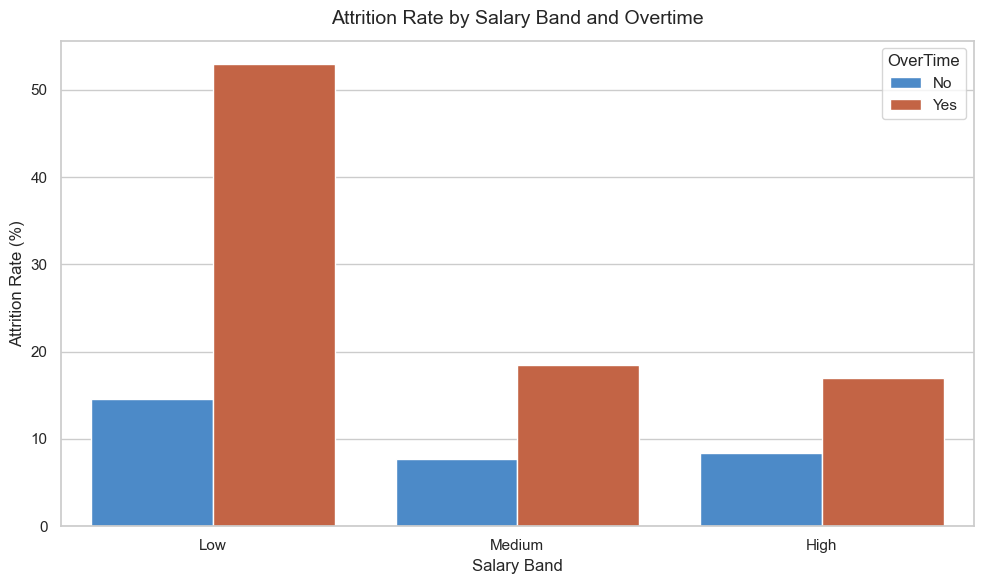

In [51]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_df,
    x="SalaryBand",
    y="AttritionRate",
    hue="OverTime",
    palette=palette
)

plt.title("Attrition Rate by Salary Band and Overtime", fontsize=14, pad=12)
plt.xlabel("Salary Band")
plt.ylabel("Attrition Rate (%)")
plt.legend(title="OverTime")
plt.tight_layout()

plt.savefig("../images/attrition_salary_overtime.png", dpi=300, bbox_inches="tight")
plt.show()


Employees with lower salaries who work overtime show the highest attrition rates.

Overtime increases attrition across all salary bands, while higher salaries help reduce this effect.

In [52]:
plot_overtime = (
    df.groupby("OverTime")["Exited"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
  )
print(plot_overtime)

  OverTime  Exited
0       No   10.44
1      Yes   30.53


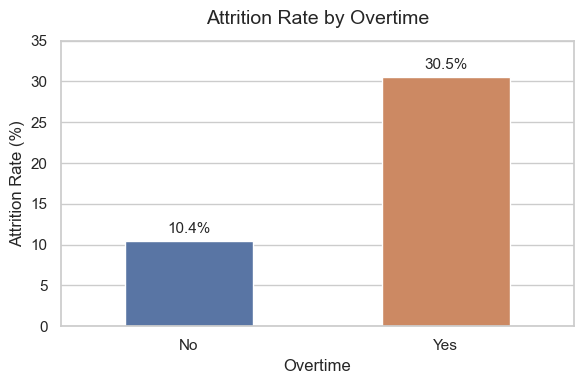

In [53]:
plt.figure(figsize=(6, 4))

sns.barplot(
    data=plot_overtime,
    x="OverTime",
    y="Exited",
    hue="OverTime",
    palette={"No": "#4C72B0", "Yes": "#DD8452"},
    legend=False,
    width=0.5
)

for i, v in enumerate(plot_overtime["Exited"]):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=11)

plt.title("Attrition Rate by Overtime", fontsize=14, pad=12)
plt.xlabel("Overtime")
plt.ylabel("Attrition Rate (%)")
plt.ylim(0, 35)

plt.tight_layout()

plt.savefig("../images/plot_overtime.png", dpi=300, bbox_inches="tight")
plt.show()

Employees who work overtime show significantly higher attrition rates compared to those who do not.

In [54]:
attrition_department = ( 
  df.groupby("Department")["Exited"] 
  .mean()
  .mul(100)
  .round(2)
  .reset_index() 
  ) 
print(attrition_department)

               Department  Exited
0         Human Resources   19.05
1  Research & Development   13.84
2                   Sales   20.63


Employees in the Sales department show the highest attrition rate, which may reflect the high-pressure nature of sales roles.

Human Resources also presents a relatively high attrition rate, only slightly below Sales, suggesting that this department may require further investigation to better understand the drivers of employee turnover.

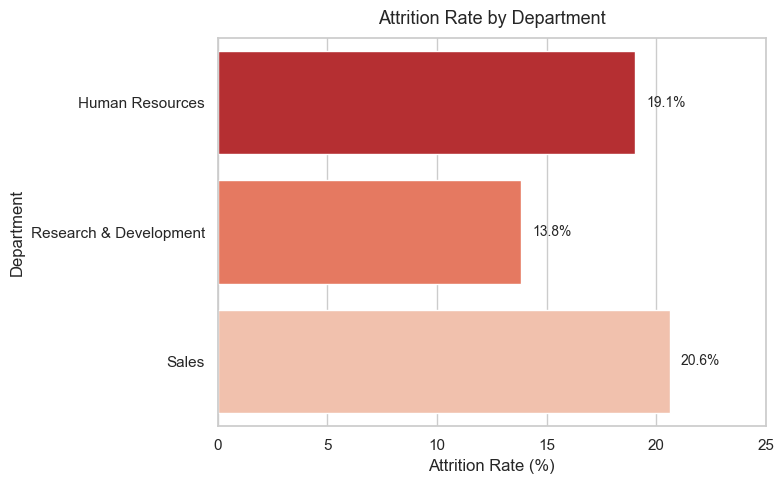

In [55]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=attrition_department,
    y="Department",
    x="Exited",
    hue="Department",
    palette="Reds_r",
    legend=False
)

for i, v in enumerate(attrition_department["Exited"]):
    plt.text(v + 0.5, i, f"{v:.1f}%", va='center', fontsize=10)

plt.title("Attrition Rate by Department", fontsize=13, pad=10)
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Department")

plt.xlim(0, 25)

plt.tight_layout()

plt.savefig("../images/attrition_department.png", dpi=300, bbox_inches="tight")
plt.show()

Sales shows the highest attrition rate. Human Resources also presents a relatively high level of turnover, while Research & Development, although lower, remains close to the other departments.

In [56]:
attrition_jobsatisfaction = ( 
  df.groupby("JobSatisfaction")["Exited"] 
  .mean()
  .mul(100)
  .round(2)
  .reset_index() 
  ) 
print(attrition_jobsatisfaction)

   JobSatisfaction  Exited
0                1   22.84
1                2   16.43
2                3   16.52
3                4   11.33


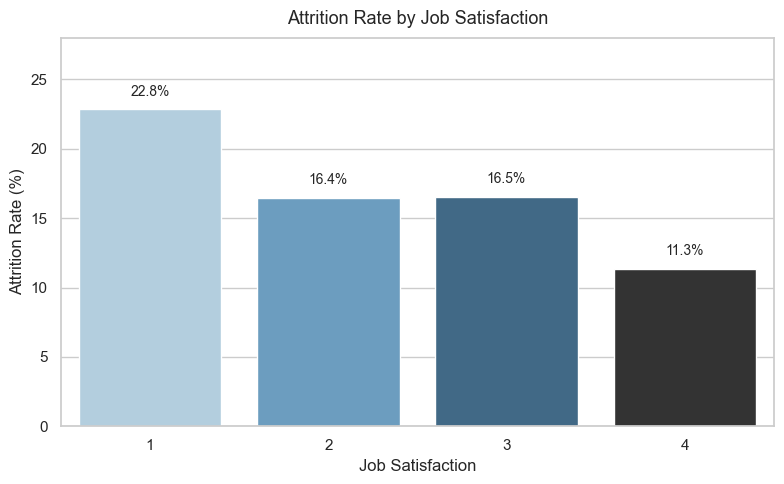

In [57]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=attrition_jobsatisfaction,
    x="JobSatisfaction",
    y="Exited",
    hue="JobSatisfaction",
    palette="Blues_d",
    legend=False
)

for i, v in enumerate(attrition_jobsatisfaction["Exited"]):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=10)

plt.title("Attrition Rate by Job Satisfaction", fontsize=13, pad=10)
plt.xlabel("Job Satisfaction")
plt.ylabel("Attrition Rate (%)")
plt.ylim(0, 28)

plt.tight_layout()

plt.savefig("../images/attrition_job_satisfaction.png", dpi=300, bbox_inches="tight")
plt.show()

Employees with lower levels of job satisfaction show higher attrition rates, while those with higher satisfaction tend to be more stable.

Mid-level satisfaction groups display similar behavior, suggesting that the most significant difference occurs between the lowest and highest levels.

In [58]:
df["TenureGroup"] = pd.cut(
    df["YearsAtCompany"],
    bins=[-1, 2, 7, float("inf")],
    labels=["Early", "Mid", "Senior"]
)
tenure_df = df.groupby("TenureGroup")["Exited"].mean().mul(100).round(2).reset_index()

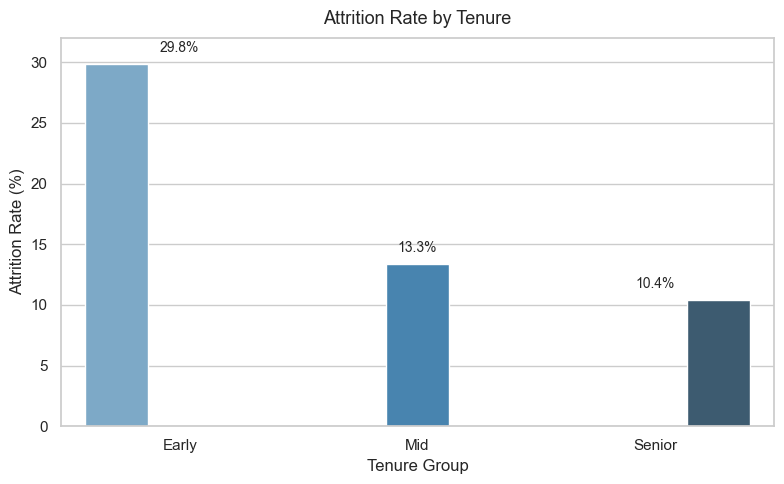

In [59]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=tenure_df,
    x="TenureGroup",
    y="Exited",
    hue="TenureGroup",
    palette="Blues_d",
    legend=False
)

for i, v in enumerate(tenure_df["Exited"]):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=10)

plt.title("Attrition Rate by Tenure", fontsize=13, pad=10)
plt.xlabel("Tenure Group")
plt.ylabel("Attrition Rate (%)")
plt.ylim(0, 32)

plt.tight_layout()

plt.savefig("../images/attrition_tenure.png", dpi=300, bbox_inches="tight")
plt.show()

Employees with shorter tenure show significantly higher attrition rates.

As time at the company increases, attrition rates decrease, indicating greater stability among more experienced employees.

## 🗄️ SQL Validation

In [60]:
# Create in-memory SQLite database for SQL validation
import sqlite3

conn = sqlite3.connect(":memory:")
df.to_sql("employees", conn, index=False)

1470

### Attrition by Salary Band (SQL)

In [61]:
query = """
SELECT 
    CASE 
        WHEN MonthlyIncome < 4000 THEN 'Low'
        WHEN MonthlyIncome BETWEEN 4000 AND 7000 THEN 'Medium'
        ELSE 'High'
    END AS salary_band,
    ROUND(AVG(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100, 2) AS attrition_rate
FROM employees
GROUP BY salary_band
"""

sql_result = pd.read_sql(query, conn)
sql_result

,salary_band,attrition_rate
0,High,10.80
1,Low,25.28
2,Medium,10.75


This query calculates the attrition rate across different salary bands.

A salary segmentation was created using a CASE statement, replicating the same logic applied in the Pandas analysis. The attrition rate is computed by converting the Attrition column into a binary variable (Yes = 1, No = 0) and taking the average.

The results show a clear pattern: employees in the low salary band have a significantly higher attrition rate (~25%) compared to medium and high salary groups (~10–11%), which present very similar levels.

This reinforces the idea that lower compensation is strongly associated with higher employee turnover.

### Attrition by Salary Band and Overtime (SQL)

This analysis combines salary level and overtime status to understand how these two factors interact and impact employee attrition.

In [62]:
query = """
SELECT 
    CASE 
        WHEN MonthlyIncome < 4000 THEN 'Low'
        WHEN MonthlyIncome BETWEEN 4000 AND 7000 THEN 'Medium'
        ELSE 'High'
    END AS salary_band,
    OverTime,
    ROUND(AVG(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100, 2) AS attrition_rate
FROM employees
GROUP BY salary_band, OverTime
ORDER BY salary_band, attrition_rate DESC
"""

pd.read_sql(query, conn)

,salary_band,OverTime,attrition_rate
0,High,Yes,16.94
1,High,No,8.36
2,Low,Yes,52.98
3,Low,No,14.58
4,Medium,Yes,18.44
5,Medium,No,7.67


The results reveal a strong interaction effect between salary and overtime. While overtime increases attrition across all salary bands, its impact is significantly more pronounced among lower-income employees.

Employees in the low salary band who work overtime show an extremely high attrition rate (~53%), compared to ~14.6% for those who do not. In contrast, medium and high salary groups also show higher attrition with overtime, but at much lower levels (~16–18%).

This suggests that overtime alone is not the primary driver of attrition — rather, the combination of low compensation and increased workload creates the highest risk of employee turnover.

### Attrition by Overtime (SQL)

In [63]:
query = """
SELECT 
    OverTime,
    ROUND(AVG(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100, 2) AS attrition_rate
FROM employees
GROUP BY OverTime
"""

pd.read_sql(query, conn)

,OverTime,attrition_rate
0,No,10.44
1,Yes,30.53


Employees who work overtime show a significantly higher attrition rate compared to those who do not. This confirms overtime as one of the strongest individual predictors of employee turnover in this dataset.

### Attrition by Department (SQL)

In [64]:
query = """
SELECT 
    Department,
    ROUND(AVG(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100, 2) AS attrition_rate
FROM employees
GROUP BY Department
ORDER BY attrition_rate DESC
"""

pd.read_sql(query, conn)

,Department,attrition_rate
0,Sales,20.63
1,Human Resources,19.05
2,Research & Development,13.84


Sales presents the highest attrition rate, consistent with the high-pressure nature of the role. Human Resources follows closely, while Research & Development shows the lowest turnover among the three departments. These results are fully aligned with the Pandas analysis.

### Attrition by Job Satisfaction (SQL)

In [65]:
query = """
SELECT 
    JobSatisfaction,
    ROUND(AVG(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100, 2) AS attrition_rate
FROM employees
GROUP BY JobSatisfaction
ORDER BY JobSatisfaction
"""

pd.read_sql(query, conn)

,JobSatisfaction,attrition_rate
0,1,22.84
1,2,16.43
2,3,16.52
3,4,11.33


There is a clear inverse relationship between job satisfaction and attrition. Employees at the lowest satisfaction level (1) show the highest turnover, while those at the highest level (4) show the lowest. Mid-level satisfaction groups (2 and 3) behave similarly, suggesting the most critical gap is between the extremes.

### Attrition by Tenure (SQL)

In [66]:
query = """
SELECT 
    CASE 
        WHEN YearsAtCompany <= 2 THEN 'Early'
        WHEN YearsAtCompany BETWEEN 3 AND 7 THEN 'Mid'
        ELSE 'Senior'
    END AS tenure_group,
    ROUND(AVG(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100, 2) AS attrition_rate
FROM employees
GROUP BY tenure_group
"""

pd.read_sql(query, conn)

,tenure_group,attrition_rate
0,Early,29.82
1,Mid,13.33
2,Senior,10.42


Early-tenure employees (up to 2 years) show the highest attrition rate by a significant margin. Attrition decreases steadily as tenure grows, with senior employees showing the lowest turnover. This reinforces that the first two years are the most critical window for retention efforts.